# Crux — Climbing CV: from holds to a climb debrief
### One self-contained notebook — every coder's work, end to end

A vision system that (1) **detects climbing holds** with a fine-tuned YOLO detector — *the graded transfer-learning core* — and (2) fuses it with **pretrained body pose** to infer, per frame, **which holds the climber is using** and the **reach to the next hold**, rendered as an overlay demo.

> **Self-contained by design.** All code is written *into this notebook* — nothing is cloned or imported from the repo. The graded results (metrics + figures) are embedded from the real training run, and re-running needs no GitHub checkout.

**Who built what** (task split in `extras/climbing-cv-work-split-v3.md`):

| Role | Owner | Where in this notebook |
|---|---|---|
| **Data** | Diego | §A1 — Roboflow dataset → single class `hold`, 640 px |
| **Model** | Coder 1 | §A2–A4 — fine-tune YOLO26, evaluate, freeze `best.pt` — *graded core* |
| **Integration** | Coder 2 | **Part B** — static hold map + pose + association + reach + demo |
| Narrative / Results | Presenters | slides + README (outside the notebook) |

**Architecture**
```
empty-wall frame ─► Hold detector (fine-tuned, run ONCE) ─► static hold map ─┐
                                                                             ├─► associate ─► reach ─► overlay ─► demo
each frame       ─► Pose model (pretrained, per frame) ──► 17 keypoints ─────┘
```
Both models run on the same frame, so their outputs already share one pixel space.

**How to run**
- **Part A (graded core):** the fine-tune/eval code is inlined and runnable on a GPU *if* you supply the dataset (§A1, optional). By default it **doesn't run** — the real results are shown as embedded figures, so nothing is required to read or submit it.
- **Part B (integration demo):** inlined end to end. Give it the frozen `best.pt` + a short climbing clip (local path or Colab upload); pretrained pose auto-downloads. Real rendered outputs are embedded as a fallback.

## Setup
Install the two libraries the notebook needs. `ultralytics` pulls in Torch, OpenCV and NumPy; `roboflow` is only for the optional dataset re-download in §A1.

In [ ]:
%pip install -q ultralytics roboflow

## Configuration
Everything the code reads — image size, class list, training knobs, pipeline thresholds — lives in this one dict (the inlined equivalent of the project's `config.yaml`). **Image size is locked at 640** for train, eval and inference.

In [ ]:
from pathlib import Path
import logging
logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")

CFG = {
    "image_size": 640,                 # locked across train / eval / inference
    "classes": ["hold"],               # single class — WHERE the holds are
    "training": {"model": "yolo26n.pt", "epochs": 80, "batch": 16,
                 "lr0": 0.01, "patience": 20, "seed": 42},
    "augmentation": {"fliplr": 0.5, "flipud": 0.0, "brightness": 0.2, "rotation_deg": 10},
    "pipeline": {"association_margin_px": 15, "min_contact_frames": 3,
                 "empty_frame_samples": 80, "stabilize_max_features": 2000},
}

# Inputs (no repo needed): point these at local files, or upload on Colab (see B0).
WEIGHTS   = Path("best.pt")            # the frozen detector (Part A output)
DATA_YAML = Path("data/data.yaml")     # only needed to re-train Part A
print("config ready — image_size", CFG["image_size"], "| classes", CFG["classes"])

---
# Part A — The graded core: a transfer-learning hold detector
*Owners: Diego (Data) · Coder 1 (Model)*

**The graded result.** `yolo26n.pt` is pretrained on **COCO**, which has **no `hold` class** — so it scores ~0 mAP on climbing holds. We **fine-tune** it on a single-class `hold` dataset (~417 images, 640×640) and measure the **before → after mAP gain**. That gain *is* the transfer-learning result.

The training/eval code below is the real logic (inlined from `training/train.py` + `eval.py`); it runs on a GPU when a dataset is present. The **results shown are from the actual run**.

## A1. Data (Diego) — *optional*, never blocks
The dataset is a Roboflow project (single class `hold`, resized to 640, ~417 images), built by Diego's scripted pipeline (download → clean → split → export). Re-downloading needs a Roboflow API key, so it is **off by default** — flip `FETCH_DATA = True` only if you want to re-train.

In [ ]:
import os
FETCH_DATA = False   # True -> re-pull the dataset (needs a Roboflow API key)

if FETCH_DATA and not DATA_YAML.exists():
    key = os.environ.get("ROBOFLOW_API_KEY")
    if not key:
        print("Set os.environ['ROBOFLOW_API_KEY'] to fetch the dataset — skipping for now.")
    else:
        from roboflow import Roboflow
        ds = (Roboflow(api_key=key).workspace("diego-alfaro-s-workspace")
              .project("climbing-replica-test-bdtpi").version(3)
              .download("yolov11", location="data"))
        DATA_YAML = Path(ds.location) / "data.yaml"
        print("Dataset ->", DATA_YAML)
else:
    print(f"Data step skipped (FETCH_DATA={FETCH_DATA}). Using the recorded results below.")

## A2. Fine-tune (transfer learning)
Load the COCO-pretrained checkpoint and fine-tune on the `hold` dataset. Every knob comes from `CFG` (Ultralytics has no literal *brightness* — HSV-value is the standard proxy). The best checkpoint is copied to `best.pt`, the one frozen detector Part B consumes.

In [ ]:
import shutil

def pick_device():
    # CUDA on Colab, MPS on Apple Silicon, else CPU.
    try:
        import torch
    except ImportError:
        return "cpu"
    if torch.cuda.is_available(): return "0"
    if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available(): return "mps"
    return "cpu"

def build_train_kwargs(cfg, data_yaml, project):
    t, aug = cfg["training"], cfg.get("augmentation", {})
    return {
        "data": str(data_yaml), "imgsz": cfg["image_size"],
        "epochs": t["epochs"], "batch": t["batch"], "lr0": t["lr0"],
        "patience": t["patience"], "seed": t["seed"], "deterministic": True,
        "project": str(project), "name": "finetune", "device": pick_device(),
        "fliplr": aug["fliplr"], "flipud": aug["flipud"],
        "hsv_v": aug["brightness"], "degrees": aug["rotation_deg"],   # brightness ~= HSV value
    }

def train_detector(cfg, data_yaml, weights_out):
    from ultralytics import YOLO
    kw = build_train_kwargs(cfg, data_yaml, Path("runs"))
    res = YOLO(cfg["training"]["model"]).train(**kw)
    best = Path(res.save_dir) / "weights" / "best.pt"
    Path(weights_out).parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(best, weights_out)
    return weights_out

if DATA_YAML.exists():
    train_detector(CFG, DATA_YAML, WEIGHTS)
else:
    print("No dataset present -> skipping training. Frozen weights + results shown below.")

## A3. Evaluate — before vs. after
Validate the COCO baseline and the fine-tuned `best.pt` on the same held-out **test** split (never seen in training). COCO has no `hold` class, so its mAP is ~0 — that contrast *is* the transfer-learning story.

In [ ]:
import yaml

def report_split(data_yaml):
    root = Path(yaml.safe_load(Path(data_yaml).read_text())["path"])
    return "test" if (root / "test" / "images").exists() else "val"

def val_map(weights, data_yaml, imgsz, split, name):
    from ultralytics import YOLO
    m = YOLO(str(weights)).val(data=str(data_yaml), imgsz=imgsz, split=split, name=name)
    return float(m.box.map50), float(m.box.map)

def compare_baseline_finetuned(cfg, data_yaml, weights):
    imgsz, split = cfg["image_size"], report_split(data_yaml)
    f50, f = val_map(weights, data_yaml, imgsz, split, "eval_finetuned")
    try:
        b50, b = val_map(cfg["training"]["model"], data_yaml, imgsz, split, "eval_baseline")
    except Exception:
        b50, b = 0.0, 0.0   # COCO has no `hold` class -> no matching predictions
    return {"baseline": {"map50": b50, "map": b}, "finetuned": {"map50": f50, "map": f},
            "delta": {"map50": f50 - b50, "map": f - b}, "split": split}

if DATA_YAML.exists() and WEIGHTS.exists():
    summary = compare_baseline_finetuned(CFG, DATA_YAML, WEIGHTS)
    print(summary)
else:
    print("Recorded metrics shown below (a live re-run needs the dataset + best.pt).")

## A4. Result — the transfer-learning gain
The money shot, from the real run on the held-out **test** split:

| Model | mAP50 | mAP50-95 |
|---|---|---|
| COCO-pretrained (baseline) | 0.0077 | 0.0038 |
| **Fine-tuned (`best.pt`)** | **0.8234** | **0.4898** |
| **Δ (gain)** | **+0.8156** | **+0.4860** |

From ~0 to **0.82 mAP50** — the detector learned the `hold` class purely from fine-tuning.

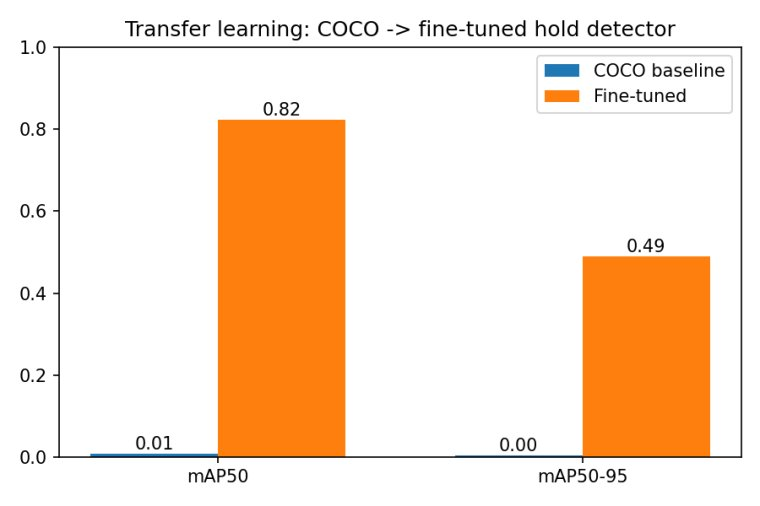

In [ ]:
import base64
from IPython.display import Image, display
# Before/after — COCO baseline vs. fine-tuned (embedded from the real fine-tuning run — self-contained)
_fig = "..."
display(Image(base64.b64decode(_fig), width=460))

## A5. Training curves, PR curve & confusion matrix

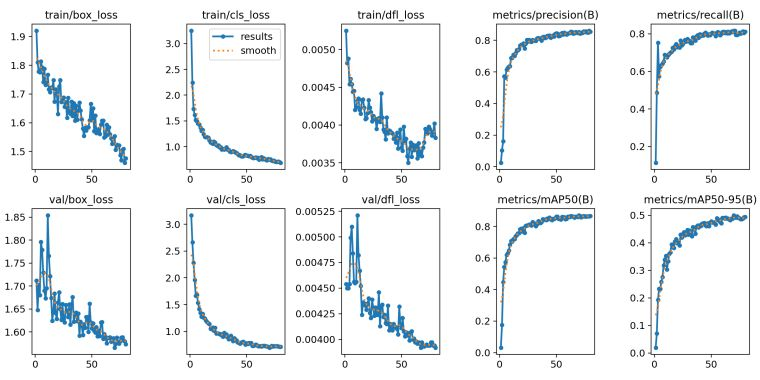

In [ ]:
import base64
from IPython.display import Image, display
# Training curves (loss + metrics per epoch) (embedded from the real fine-tuning run — self-contained)
_fig = "..."
display(Image(base64.b64decode(_fig), width=460))

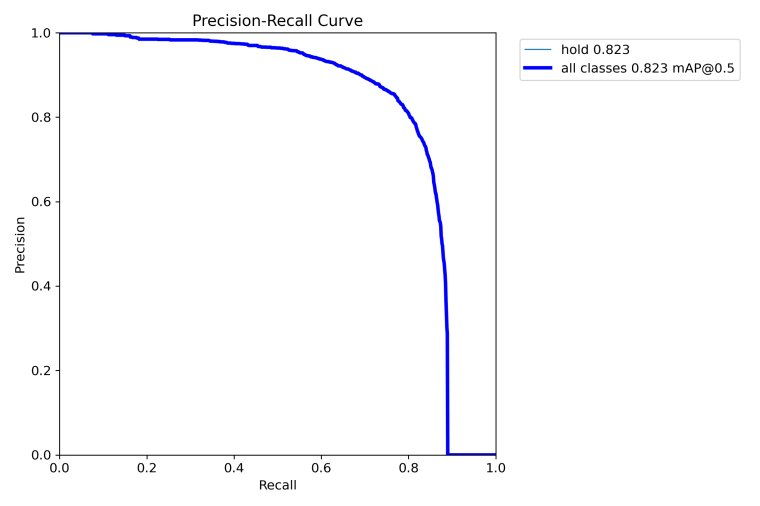

In [ ]:
import base64
from IPython.display import Image, display
# Precision-Recall curve (fine-tuned) (embedded from the real fine-tuning run — self-contained)
_fig = "..."
display(Image(base64.b64decode(_fig), width=460))

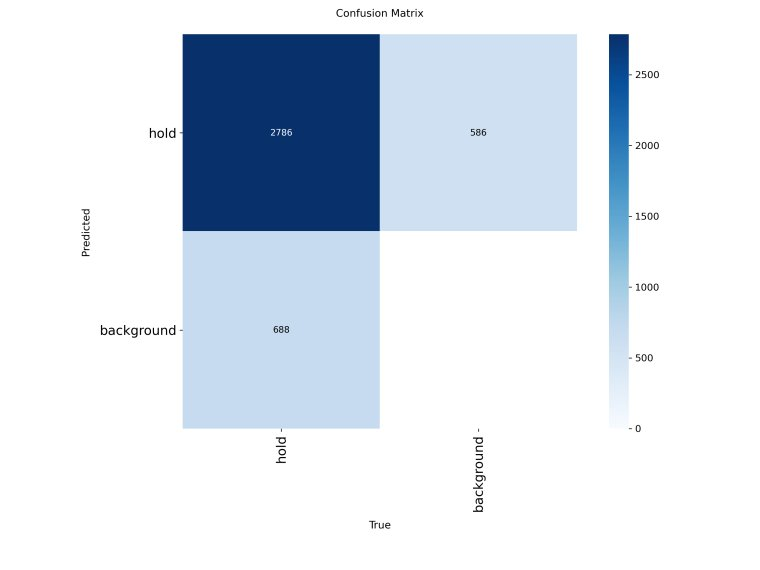

In [ ]:
import base64
from IPython.display import Image, display
# Confusion matrix (hold vs. background) (embedded from the real fine-tuning run — self-contained)
_fig = "..."
display(Image(base64.b64decode(_fig), width=460))

## A6. Sample detections (held-out test images)
The frozen detector run on unseen test images — the boxes it draws are exactly the static hold map Part B consumes.

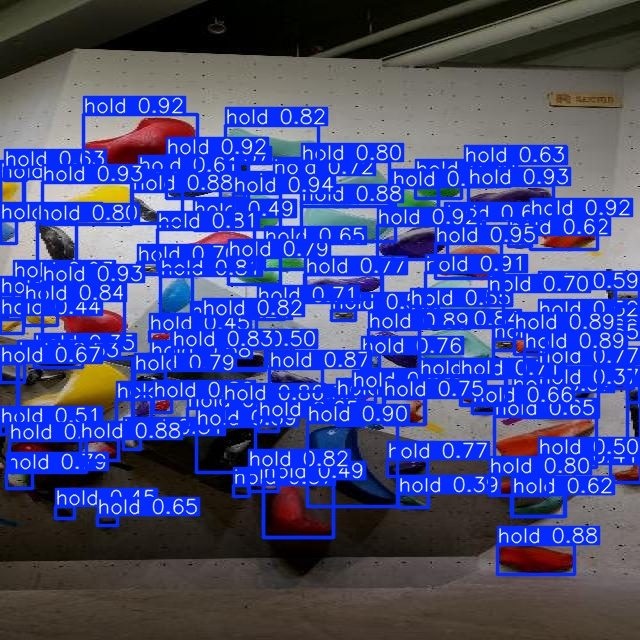

In [ ]:
import base64
from IPython.display import Image, display
# Sample detection — test image (embedded from the real fine-tuning run — self-contained)
_fig = "..."
display(Image(base64.b64decode(_fig), width=460))

---
# Part B — Integration: which holds, and the reach to the next
*Owner: Coder 2 (Integration). Consumes the frozen `best.pt` from Part A.*

The applied extension and demo wow-factor: fuse the frozen hold detector with **pretrained body pose** to *read a climb*. The whole pipeline is inlined below (from `pipeline/`).

**Key design decision — the static hold map.** The body occludes holds *exactly* when a hand or foot is on them, so per-frame detection drops the holds you care about most. Instead we detect holds **once** on the empty wall, then run **only pose** per frame and associate the climber against that fixed map.

**Graceful degradation is a rule:** every overlay layer is optional, so the demo still draws the hold map + skeleton even when a contact or the reach line is missing.

## B0. Inputs — no repo, no clone
Part B needs two files: the frozen detector `best.pt` and a short climbing clip from a fixed camera. Use local paths if present, otherwise upload them on Colab. The pretrained pose model auto-downloads on first use.

In [ ]:
import cv2, numpy as np, math, json
from pathlib import Path

CLIP = Path("clip.mp4")
if not WEIGHTS.exists() and Path("models/best.pt").exists():
    WEIGHTS = Path("models/best.pt")

if not WEIGHTS.exists() or not CLIP.exists():
    try:
        from google.colab import files
        print("Upload the frozen detector (best.pt) and a climbing clip (.mp4):")
        for name in files.upload():
            if name.endswith(".pt"): WEIGHTS = Path(name)
            elif name.lower().endswith((".mp4", ".mov", ".avi")): CLIP = Path(name)
    except Exception:
        print("Not on Colab — place best.pt + clip.mp4 beside the notebook, or set WEIGHTS/CLIP.")
print("weights:", WEIGHTS, WEIGHTS.exists(), "| clip:", CLIP, CLIP.exists())

## B1. Static hold map — camera stabilization + empty-wall synthesis + detect once
Our footage has no clean empty-wall shot, so we synthesize one: register frames to a reference (ORB + RANSAC) to cancel handheld drift, take the per-pixel **temporal median** (the moving climber is outvoted → bare wall), then run the detector on it **once**.

In [ ]:
# ── inlined from pipeline/stabilize.py — cancel handheld camera drift (Coder 2) ──
from __future__ import annotations

import cv2
import numpy as np

MATCHES_KEPT = 200  # best matches fed to the RANSAC transform estimate


class Stabilizer:
    """Aligns frames to a fixed reference frame via an ORB-based similarity transform."""

    def __init__(self, reference_bgr: np.ndarray, max_features: int = 2000, min_matches: int = 12):
        self.size = (reference_bgr.shape[1], reference_bgr.shape[0])  # (w, h) for warpAffine
        self.min_matches = min_matches
        self._orb = cv2.ORB_create(max_features)
        self._bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
        gray = cv2.cvtColor(reference_bgr, cv2.COLOR_BGR2GRAY)
        self._kref, self._dref = self._orb.detectAndCompute(gray, None)
        if self._dref is None:
            raise ValueError("Reference frame has no detectable features to stabilize against.")

    def affine(self, frame_bgr: np.ndarray) -> np.ndarray | None:
        """2x3 similarity transform mapping ``frame_bgr`` -> reference, or None if unreliable.

        RANSAC rejects the climber's motion as outliers, so the fit locks onto the
        static wall even though the reference frame contains the climber.
        """
        gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
        kp, desc = self._orb.detectAndCompute(gray, None)
        if desc is None or len(kp) < self.min_matches:
            return None
        matches = self._bf.match(desc, self._dref)
        if len(matches) < self.min_matches:
            return None
        matches = sorted(matches, key=lambda m: m.distance)[:MATCHES_KEPT]
        src = np.float32([kp[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
        dst = np.float32([self._kref[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)
        M, _ = cv2.estimateAffinePartial2D(src, dst, method=cv2.RANSAC)
        return M

    def warp(self, frame_bgr: np.ndarray, M: np.ndarray | None = None) -> np.ndarray:
        """Warp a frame into reference space. Estimates ``M`` if not given; on failure
        returns the frame untouched (graceful — one unalignable frame won't crash a run)."""
        if M is None:
            M = self.affine(frame_bgr)
        if M is None:
            return frame_bgr
        return cv2.warpAffine(frame_bgr, M, self.size, flags=cv2.INTER_LINEAR,
                              borderMode=cv2.BORDER_REPLICATE)

In [ ]:
# ── inlined from pipeline/empty_frame.py — synthesize the empty wall + stabilized clip ──
from __future__ import annotations

import logging
from pathlib import Path

import cv2
import numpy as np


logger = logging.getLogger(__name__)


def _read_frame(cap: cv2.VideoCapture, idx: int) -> np.ndarray | None:
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
    ok, frame = cap.read()
    return frame if ok else None


def reference_frame(clip: Path) -> np.ndarray:
    """The clip's middle frame — used as the fixed coordinate space everything maps into."""
    cap = cv2.VideoCapture(str(clip))
    if not cap.isOpened():
        raise FileNotFoundError(f"Could not open clip: {clip}")
    nf = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frame = _read_frame(cap, nf // 2)
    cap.release()
    if frame is None:
        raise FileNotFoundError(f"Could not read a frame from: {clip}")
    return frame


def build_empty_frame(clip: Path, stab: Stabilizer, n_samples: int = 80) -> np.ndarray:
    """Stabilized temporal-median empty wall: sample, warp to reference, median over time."""
    cap = cv2.VideoCapture(str(clip))
    nf = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    idxs = np.linspace(0, nf - 1, min(n_samples, nf)).astype(int)
    warped = [stab.warp(f) for f in (_read_frame(cap, i) for i in idxs) if f is not None]
    cap.release()
    if not warped:
        raise ValueError(f"No frames sampled from: {clip}")
    return np.median(np.stack(warped), axis=0).astype(np.uint8)


def write_stabilized_clip(clip: Path, stab: Stabilizer, out: Path) -> Path:
    """Warp every frame into reference space and write the stabilized clip to ``out``."""
    cap = cv2.VideoCapture(str(clip))
    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    writer = cv2.VideoWriter(str(out), cv2.VideoWriter_fourcc(*"mp4v"), fps, stab.size)
    n = 0
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        writer.write(stab.warp(frame))
        n += 1
    cap.release()
    writer.release()
    logger.info("Stabilized %d frames -> %s", n, out)
    return out


def prepare(clip: Path, work_dir: Path, n_samples: int = 80, max_features: int = 2000) -> tuple[Path, Path]:
    """Build (empty_frame.jpg, stabilized_clip.mp4) from a raw clip; returns their paths."""
    work_dir.mkdir(parents=True, exist_ok=True)
    stab = Stabilizer(reference_frame(clip), max_features=max_features)
    empty = build_empty_frame(clip, stab, n_samples)
    empty_path = work_dir / f"{clip.stem}_empty.jpg"
    cv2.imwrite(str(empty_path), empty)
    logger.info("Empty wall -> %s", empty_path)
    stab_clip = write_stabilized_clip(clip, stab, work_dir / f"{clip.stem}_stabilized.mp4")
    return empty_path, stab_clip

In [ ]:
# ── inlined from pipeline/holds_map.py — detect holds ONCE -> the static hold map ──
from __future__ import annotations

import json
import logging
from pathlib import Path


logger = logging.getLogger(__name__)


def build_hold_map(empty_frame: Path, weights: Path, imgsz: int, conf: float = 0.25) -> list[dict]:
    """Detect holds on the empty-wall frame → ``[{"xyxy", "conf", "cls"}, ...]``.

    Runs the frozen detector ONCE at ``imgsz``. Boxes come back in the frame's own
    pixel space, which is the same space pose runs in (same fixed camera), so no
    rescaling is needed downstream. Holds are sorted top→bottom, left→right so the
    map indices are stable across runs.
    """
    from ultralytics import YOLO  # heavy; imported lazily so the module stays importable

    if not empty_frame.is_file():
        raise FileNotFoundError(f"Empty-wall frame not found: {empty_frame}")
    if not weights.is_file():
        raise FileNotFoundError(f"Detector weights not found: {weights}")

    result = YOLO(str(weights)).predict(str(empty_frame), imgsz=imgsz, conf=conf, verbose=False)[0]
    holds = [
        {
            "xyxy": [round(float(v), 1) for v in box.xyxy[0].tolist()],
            "conf": round(float(box.conf[0]), 4),
            "cls": int(box.cls[0]),
        }
        for box in result.boxes
    ]
    holds.sort(key=lambda h: (h["xyxy"][1], h["xyxy"][0]))  # stable top→bottom, left→right
    return holds


def run(cfg: dict, paths: Paths, empty_frame: Path, out: Path) -> Path:
    holds = build_hold_map(empty_frame, paths.weights, cfg["image_size"])
    out.parent.mkdir(parents=True, exist_ok=True)
    out.write_text(json.dumps(holds, indent=2), encoding="utf-8")
    logger.info("Wrote %d holds -> %s", len(holds), out)
    return out

## B2. Pose, association & reach
- **Pose** — pretrained COCO 17-keypoint model, per frame, same pixel space as the map.
- **Association** — a hold is *in use* when a wrist/ankle sits in its box (+margin) for ≥ N consecutive frames (the debounce kills pose jitter).
- **Reach** — from the higher hand, the nearest *unused* hold above it; distance ÷ shoulder→wrist length gives a body-scale *"how far to reach"*.

In [ ]:
# ── inlined from pipeline/pose.py — pretrained per-frame body pose (Coder 2) ──
from __future__ import annotations

import logging
from pathlib import Path

logger = logging.getLogger(__name__)

POSE_MODEL = "yolo11n-pose.pt"   # pretrained COCO 17-keypoint


def pose_per_frame(clip: Path, imgsz: int = 640, model: str = POSE_MODEL, conf: float = 0.25):
    """Yield, per frame, the climber's 17 ``[x, y, conf]`` keypoints (or ``None``).

    Streams the clip so memory stays flat on long videos. When several people are
    detected we keep the highest-confidence one (the climber); when none are, we
    yield ``None`` so downstream steps can degrade gracefully on that frame.
    Keypoints are in the frame's own pixel space — the same space as the hold map.
    """
    from ultralytics import YOLO  # heavy; imported lazily so the module stays importable

    if not clip.is_file():
        raise FileNotFoundError(f"Clip not found: {clip}")

    for result in YOLO(model).predict(str(clip), stream=True, imgsz=imgsz, conf=conf, verbose=False):
        kpts = result.keypoints
        if kpts is None or kpts.data is None or len(kpts.data) == 0:
            yield None
            continue
        # pick the most confident person if the detector found more than one
        if result.boxes is not None and len(result.boxes) > 1:
            best = int(result.boxes.conf.argmax())
        else:
            best = 0
        yield kpts.data[best].tolist()  # 17 x [x, y, conf]

In [ ]:
# ── inlined from pipeline/associate.py — which holds each hand/foot is on (Coder 2) ──
from __future__ import annotations

# COCO-17 keypoint indices for the limbs we track.
L_WRIST, R_WRIST = 9, 10
L_ANKLE, R_ANKLE = 15, 16
LIMB_KPT: dict[str, int] = {
    "left_hand": L_WRIST,
    "right_hand": R_WRIST,
    "left_foot": L_ANKLE,
    "right_foot": R_ANKLE,
}
KPT_CONF_MIN = 0.30  # ignore keypoints the pose model is unsure about


def _point_in_box(x: float, y: float, box: list[float], margin: int) -> bool:
    x1, y1, x2, y2 = box
    return (x1 - margin) <= x <= (x2 + margin) and (y1 - margin) <= y <= (y2 + margin)


def _hold_for_point(x: float, y: float, hold_map: list[dict], margin: int) -> int | None:
    """Index of the hold whose (expanded) box contains the point; nearest center wins ties."""
    best, best_d = None, None
    for i, hold in enumerate(hold_map):
        box = hold["xyxy"]
        if _point_in_box(x, y, box, margin):
            cx, cy = (box[0] + box[2]) / 2, (box[1] + box[3]) / 2
            d = (x - cx) ** 2 + (y - cy) ** 2
            if best_d is None or d < best_d:
                best, best_d = i, d
    return best


def associate_frame(hold_map: list[dict], keypoints, margin_px: int) -> dict[str, int | None]:
    """Raw (un-debounced) ``limb -> hold index`` for ONE frame.

    Returns every limb mapped to ``None`` when the frame has no detected climber or
    the keypoint is low-confidence / on no hold.
    """
    out: dict[str, int | None] = {limb: None for limb in LIMB_KPT}
    if keypoints is None:
        return out
    for limb, idx in LIMB_KPT.items():
        x, y, conf = keypoints[idx][0], keypoints[idx][1], keypoints[idx][2]
        if conf < KPT_CONF_MIN:
            continue
        out[limb] = _hold_for_point(x, y, hold_map, margin_px)
    return out


def associate(hold_map: list[dict], keypoints_per_frame: list, margin_px: int, min_frames: int) -> list[dict]:
    """Per-frame CONFIRMED contacts with an N-frame debounce.

    Returns a list (one entry per frame) of ``{limb: hold_index | None}``. A limb's
    hold is only reported once the limb has sat in that same hold for >=
    ``min_frames`` consecutive frames; it drops back to ``None`` the moment the limb
    leaves all holds. While a limb is moving to a new hold but not yet confirmed, it
    reports ``None`` (no phantom contact on the hold being left).
    """
    confirmed: list[dict] = []
    streak_hold: dict[str, int | None] = {limb: None for limb in LIMB_KPT}
    streak_len: dict[str, int] = {limb: 0 for limb in LIMB_KPT}
    active: dict[str, int | None] = {limb: None for limb in LIMB_KPT}

    for keypoints in keypoints_per_frame:
        raw = associate_frame(hold_map, keypoints, margin_px)
        for limb in LIMB_KPT:
            h = raw[limb]
            if h is None:
                streak_hold[limb], streak_len[limb], active[limb] = None, 0, None
            elif h == streak_hold[limb]:
                streak_len[limb] += 1
                if streak_len[limb] >= min_frames:
                    active[limb] = h
            else:  # moved to a different hold — restart the streak
                streak_hold[limb], streak_len[limb] = h, 1
                active[limb] = h if min_frames <= 1 else None
        confirmed.append(dict(active))
    return confirmed

In [ ]:
# ── inlined from pipeline/reach.py — reach to the next hold (Coder 2) ──
from __future__ import annotations

import math

# COCO-17 keypoint indices.
L_SHOULDER, R_SHOULDER = 5, 6
L_WRIST, R_WRIST = 9, 10
KPT_CONF_MIN = 0.30

# Distance normalization guards. A heavily foreshortened arm (e.g. on an overhang)
# gives a tiny shoulder->wrist length that blows the ratio up, so we only normalize
# when the arm is plausibly long and the result is sane; otherwise report None and
# let the overlay fall back to a raw-pixel label.
MIN_ARM_PX = 20.0
MAX_NORM = 4.0


def _point(keypoints, idx: int) -> tuple[float, float] | None:
    """(x, y) of a keypoint, or None when it's missing / low-confidence."""
    x, y, conf = keypoints[idx][0], keypoints[idx][1], keypoints[idx][2]
    return (x, y) if conf >= KPT_CONF_MIN else None


def _hold_centers(hold_map: list[dict]) -> list[tuple[float, float]]:
    return [((b["xyxy"][0] + b["xyxy"][2]) / 2, (b["xyxy"][1] + b["xyxy"][3]) / 2) for b in hold_map]


def reach_frame(hold_map: list[dict], keypoints, used_holds: set[int]) -> dict | None:
    """Reach from the higher hand to the nearest unused hold above it (one frame).

    Returns ``{"from_xy", "to_hold", "to_xy", "distance_px", "distance_norm"}`` or
    ``None`` when there's no detected hand or no candidate hold above it.
    """
    if keypoints is None or not hold_map:
        return None

    hands = []  # (wrist_xy, shoulder_idx)
    for wrist_idx, shoulder_idx in ((L_WRIST, L_SHOULDER), (R_WRIST, R_SHOULDER)):
        p = _point(keypoints, wrist_idx)
        if p is not None:
            hands.append((p, shoulder_idx))
    if not hands:
        return None
    (hx, hy), shoulder_idx = min(hands, key=lambda t: t[0][1])  # smallest y == highest hand

    centers = _hold_centers(hold_map)
    best_i, best_d = None, None
    for i, (cx, cy) in enumerate(centers):
        if i in used_holds or cy >= hy:  # skip used holds and anything not above the hand
            continue
        d = math.hypot(cx - hx, cy - hy)
        if best_d is None or d < best_d:
            best_i, best_d = i, d
    if best_i is None:
        return None

    shoulder = _point(keypoints, shoulder_idx)
    arm = math.hypot(shoulder[0] - hx, shoulder[1] - hy) if shoulder is not None else None
    norm = best_d / arm if arm and arm >= MIN_ARM_PX else None
    if norm is not None and norm > MAX_NORM:
        norm = None  # implausible (foreshortened arm / pose jitter) — fall back to pixels

    cx, cy = centers[best_i]
    return {
        "from_xy": (round(hx, 1), round(hy, 1)),
        "to_hold": best_i,
        "to_xy": (round(cx, 1), round(cy, 1)),
        "distance_px": round(best_d, 1),
        "distance_norm": round(norm, 2) if norm is not None else None,
    }


def reach_per_frame(hold_map: list[dict], keypoints_per_frame: list, contacts_per_frame: list[dict]) -> list:
    """Run :func:`reach_frame` over the clip; "used" holds come from the contacts of each frame."""
    out = []
    for keypoints, contacts in zip(keypoints_per_frame, contacts_per_frame):
        used = {h for h in contacts.values() if h is not None}
        out.append(reach_frame(hold_map, keypoints, used))
    return out

## B3. Overlay + render the demo
Draw the hold map (orange), skeleton (white), contacts (hands green / feet blue) and the next-hold reach arrow, then render the clip to a video (plus a recorded fallback so the live demo can never fail).

In [ ]:
# ── inlined from pipeline/overlay.py — draw holds + skeleton + contacts + reach (Coder 2) ──
from __future__ import annotations

import cv2

# BGR colors.
HOLD_COLOR = (0, 165, 255)     # orange outline for every hold
HAND_COLOR = (0, 200, 0)       # green — hold held by a hand
FOOT_COLOR = (255, 150, 0)     # blue — hold under a foot
SKELETON_COLOR = (240, 240, 240)
REACH_COLOR = (0, 255, 255)    # yellow reach line
HAND_LIMBS = {"left_hand", "right_hand"}

SKELETON = [(5, 7), (7, 9), (6, 8), (8, 10), (5, 6), (5, 11), (6, 12),
            (11, 12), (11, 13), (13, 15), (12, 14), (14, 16)]  # COCO 17-kpt edges
KPT_CONF_MIN = 0.30


def _draw_holds(img, hold_map, contacts) -> None:
    used: dict[int, set[str]] = {}
    if contacts:
        for limb, h in contacts.items():
            if h is not None:
                used.setdefault(h, set()).add(limb)
    for i, hold in enumerate(hold_map):
        x1, y1, x2, y2 = (int(v) for v in hold["xyxy"])
        limbs = used.get(i)
        if limbs:
            color = HAND_COLOR if any(l in HAND_LIMBS for l in limbs) else FOOT_COLOR
            overlay = img.copy()
            cv2.rectangle(overlay, (x1, y1), (x2, y2), color, -1)
            cv2.addWeighted(overlay, 0.35, img, 0.65, 0, img)  # translucent fill
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        else:
            cv2.rectangle(img, (x1, y1), (x2, y2), HOLD_COLOR, 1)


def _draw_skeleton(img, keypoints) -> None:
    if keypoints is None:
        return
    for a, b in SKELETON:
        if keypoints[a][2] >= KPT_CONF_MIN and keypoints[b][2] >= KPT_CONF_MIN:
            pa = (int(keypoints[a][0]), int(keypoints[a][1]))
            pb = (int(keypoints[b][0]), int(keypoints[b][1]))
            cv2.line(img, pa, pb, SKELETON_COLOR, 2)
    for x, y, conf in keypoints:
        if conf >= KPT_CONF_MIN:
            cv2.circle(img, (int(x), int(y)), 3, SKELETON_COLOR, -1)


def _draw_reach(img, reach) -> None:
    if not reach:
        return
    fx, fy = (int(v) for v in reach["from_xy"])
    tx, ty = (int(v) for v in reach["to_xy"])
    cv2.arrowedLine(img, (fx, fy), (tx, ty), REACH_COLOR, 2, tipLength=0.15)
    norm = reach.get("distance_norm")
    label = f"reach {norm:.2f} arm" if norm is not None else f"reach {reach['distance_px']:.0f}px"
    cv2.putText(img, label, ((fx + tx) // 2, (fy + ty) // 2 - 6),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, REACH_COLOR, 2, cv2.LINE_AA)


def draw_frame(frame, hold_map, keypoints, contacts=None, reach=None):
    """Return ``frame`` with holds + skeleton (+ contacts + reach line when available).

    Draws on a copy so the caller's frame is left untouched. Every layer is guarded,
    so missing keypoints / contacts / reach never break the basic visual.
    """
    img = frame.copy()
    _draw_holds(img, hold_map, contacts)
    _draw_skeleton(img, keypoints)
    _draw_reach(img, reach)
    return img

In [ ]:
# ── orchestration (inlined from pipeline/run.py) ──
def render(clip, holds, keypoints_per_frame, contacts_per_frame, reaches, out, fps=None):
    cap = cv2.VideoCapture(str(clip))
    if not cap.isOpened():
        raise FileNotFoundError(f"Could not open clip: {clip}")
    fps = fps or (cap.get(cv2.CAP_PROP_FPS) or 25.0)
    out.parent.mkdir(parents=True, exist_ok=True)
    writer, i, n = None, 0, len(keypoints_per_frame)
    try:
        while i < n:
            ok, frame = cap.read()
            if not ok: break
            contacts = contacts_per_frame[i] if i < len(contacts_per_frame) else None
            reach_i = reaches[i] if i < len(reaches) else None
            drawn = draw_frame(frame, holds, keypoints_per_frame[i], contacts, reach_i)
            if writer is None:
                h, w = drawn.shape[:2]
                writer = cv2.VideoWriter(str(out), cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))
            writer.write(drawn); i += 1
    finally:
        cap.release()
        if writer is not None: writer.release()
    return out

def run_pipeline(cfg, weights, clip, out, empty=None):
    p = cfg["pipeline"]
    if empty is None:   # derive the empty wall + a stabilized clip from the clip itself
        empty, clip = prepare(clip, out.parent / "_work",
                              n_samples=p["empty_frame_samples"],
                              max_features=p["stabilize_max_features"])
    holds = build_hold_map(empty, weights, cfg["image_size"])              # detect ONCE
    keypoints = list(pose_per_frame(clip, imgsz=cfg["image_size"]))        # pose per frame
    contacts = associate(holds, keypoints, p["association_margin_px"], p["min_contact_frames"])
    reaches = reach_per_frame(holds, keypoints, contacts)
    render(clip, holds, keypoints, contacts, reaches, out)
    return holds

### The static hold map (real output)
The detector run once on the synthesized empty wall — every orange box is a hold the fine-tuned model found. With no clip supplied, the cell displays the **pre-rendered result embedded below** (so re-running never wipes it).

No inputs provided — showing the pre-rendered static hold map (35 holds).


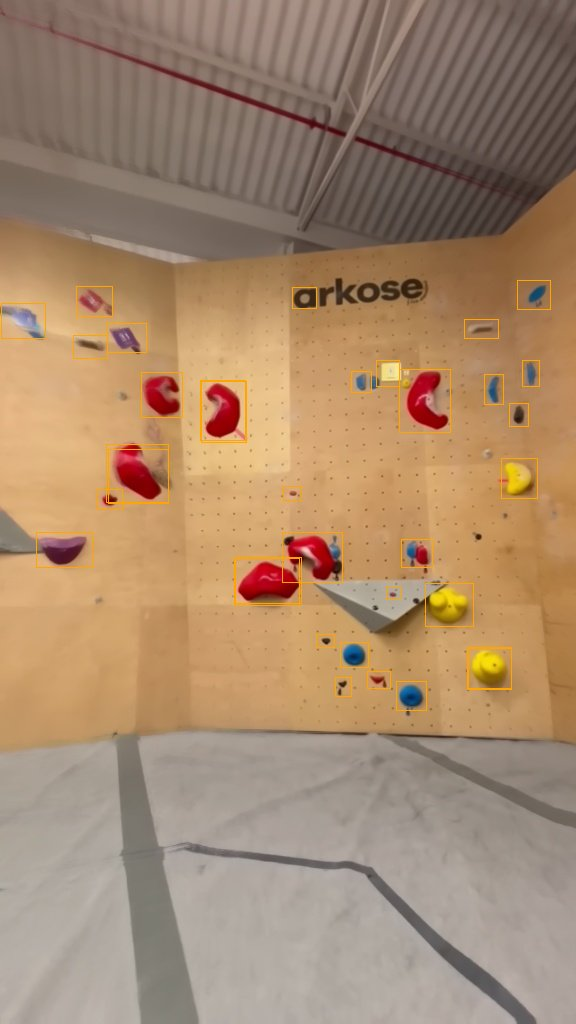

In [ ]:
import base64
from IPython.display import Image, display
_prerendered = "..."   # real output, embedded so Run-all can't destroy it

if CLIP.exists() and WEIGHTS.exists():
    empty, _ = prepare(CLIP, Path("_work"),
                       n_samples=CFG["pipeline"]["empty_frame_samples"],
                       max_features=CFG["pipeline"]["stabilize_max_features"])
    holds = build_hold_map(empty, WEIGHTS, CFG["image_size"])
    print(f"{len(holds)} holds detected on the empty wall")
    drawn = draw_frame(cv2.imread(str(empty)), holds, None)
    cv2.imwrite("_work/hold_map_overlay.jpg", drawn)
    display(Image("_work/hold_map_overlay.jpg", width=440))
else:
    print("No inputs provided — showing the pre-rendered static hold map (35 holds).")
    display(Image(base64.b64decode(_prerendered), width=440))

### The combined demo (real output)
Hold map + skeleton + lit contacts (hands green) + the next-hold reach arrow with its body-scale distance. With no clip supplied, the **pre-rendered frame embedded below** is shown; supply a clip to regenerate the full video.

No clip provided — showing the pre-rendered combined frame.


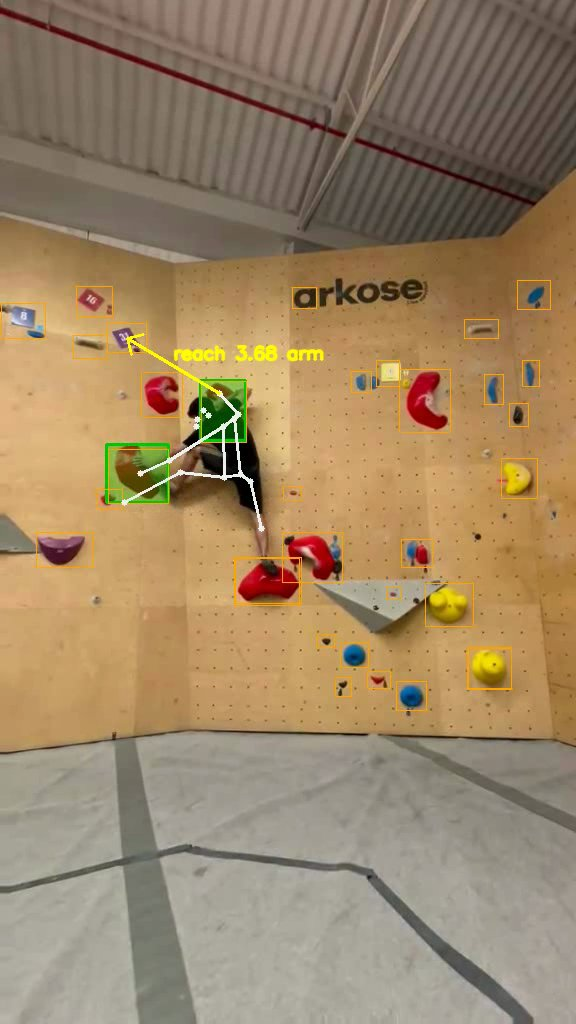

In [ ]:
_prerendered_combined = "..."   # real output, embedded (Run-all safe)

if CLIP.exists() and WEIGHTS.exists():
    holds = run_pipeline(CFG, WEIGHTS, CLIP, Path("clip_out.mp4"))
    cap = cv2.VideoCapture("clip_out.mp4")
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(0.45 * cap.get(cv2.CAP_PROP_FRAME_COUNT)))
    ok, fr = cap.read(); cap.release()
    if ok:
        cv2.imwrite("_work/combined_frame.jpg", fr)
        display(Image("_work/combined_frame.jpg", width=440))
    print("Rendered demo -> clip_out.mp4")
else:
    print("No clip provided — showing the pre-rendered combined frame.")
    display(Image(base64.b64decode(_prerendered_combined), width=440))

---
## Deliverables — end to end, in one notebook
- ✅ **Data** (Diego) — Roboflow `hold` dataset (single class, 640 px), ~417 images.
- ✅ **Model** (Jan) — fine-tuned YOLO26; **mAP50 0.008 → 0.823 (Δ +0.82)** on the held-out test split; frozen `best.pt`.
- ✅ **Integration** (Ignacio) — static hold map (35 holds) + pose + association + reach + rendered demo, with graceful degradation and a recorded fallback.

*Everything above runs from this single file — no repository checkout required.*